Generating synthetic EvoDevo dataset...
Generated 50000 data points across 500 samples
Saved long-format data to synthetic_data\evodevo_synthetic_long.csv
Saved wide-format data to synthetic_data\evodevo_synthetic_wide.csv
Generating visualization of the synthetic data...
Saved visualization to synthetic_data\evodevo_synthetic_plot.png

Dataset Generation Complete

To use with MEFISTO:
 1. Load the long-format data
 2. Map columns for MEFISTO compatibility:
    - 'sample_id' → 'sample'
    - 'organism' → 'group'
    - 'developmental_stage' → 'time'
    - 'tissue_type' → 'view'
    - 'gene_id' → 'feature'
    - 'expression_level' → 'value'
 3. Set temporal covariates using 'developmental_stage' column
 4. Use 'organism' as group variable for alignment



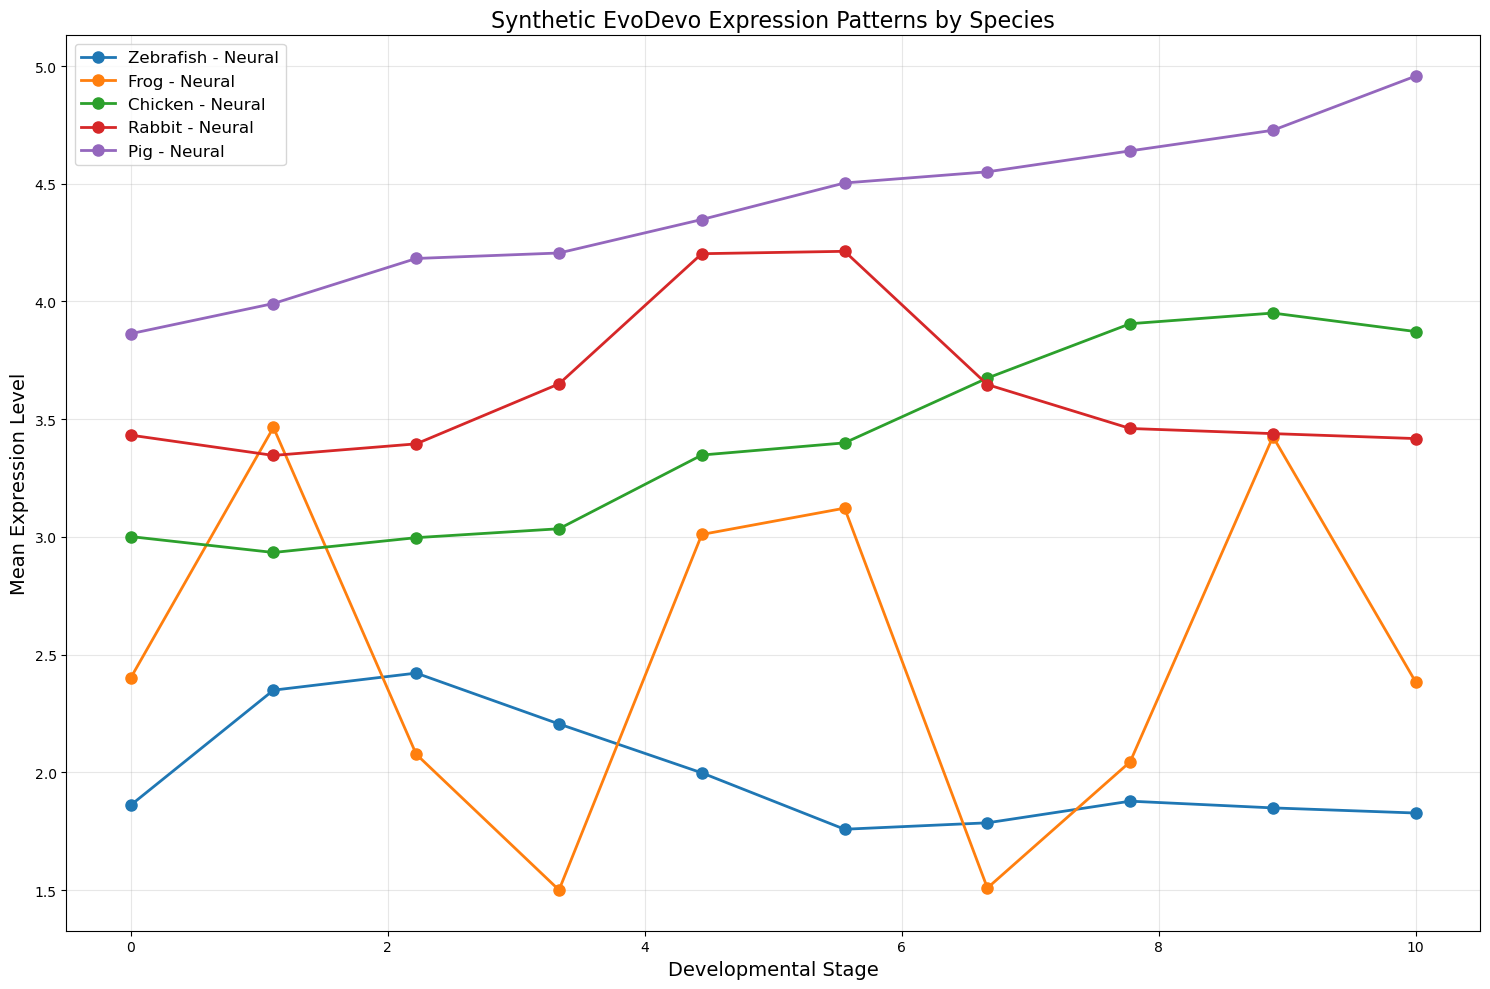

In [1]:
# Generate synthetic EvoDevo dataset for MEFISTO analysis
# Author: Your Name
# Date: March 19, 2025

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Set random seed for reproducibility
np.random.seed(42)

# Create output directory
output_dir = "synthetic_data"
os.makedirs(output_dir, exist_ok=True)

######################
# Dataset Parameters
######################

# Species (groups)
species = ["Zebrafish", "Frog", "Chicken", "Rabbit", "Pig"]

# Developmental stages (time points)
time_points = np.linspace(0, 10, 10)  # 10 developmental stages

# Tissues/organs (views)
tissues = ["Neural", "Cardiac", "Liver", "Somite", "Limb"]

# Number of genes per tissue
n_genes = 100

# Number of replicates per species/time-point combination
n_replicates = 2

######################
# Generate Data
######################

print("Generating synthetic EvoDevo dataset...")

# Create empty lists to store data
all_data = []
sample_ids = []
sample_counter = 0

# Function to generate gene expression profiles with species-specific patterns
def generate_expression(species_idx, time_point, tissue_idx, genes):
    """Generate synthetic gene expression with specific temporal patterns"""
    
    # Base expression (random variation)
    expression = np.random.lognormal(mean=0, sigma=0.5, size=len(genes))
    
    # Add species-specific baseline differences
    species_effect = np.random.normal(loc=0.5*species_idx, scale=0.2, size=len(genes))
    
    # Add time-dependent patterns that differ between species
    # Each species follows a different developmental trajectory
    if species_idx == 0:  # Zebrafish - early development
        time_effect = np.exp(-0.3 * time_point) * np.sin(np.pi * time_point/5)
    elif species_idx == 1:  # Frog - oscillatory pattern
        time_effect = np.sin(np.pi * time_point/2) 
    elif species_idx == 2:  # Chicken - sigmoidal increase
        time_effect = 1 / (1 + np.exp(-0.8 * (time_point - 5)))
    elif species_idx == 3:  # Rabbit - delayed response
        time_effect = np.exp(-0.5 * (time_point - 5)**2)
    else:  # Pig - linear increase
        time_effect = 0.1 * time_point
    
    # Add tissue-specific gene expression patterns
    tissue_pattern = np.zeros(len(genes))
    
    # Each tissue has specific gene modules
    module_size = 20
    for i in range(5):  # 5 modules per tissue
        start_idx = i * module_size
        end_idx = start_idx + module_size
        
        # Different tissues have different active modules
        if i == tissue_idx:
            tissue_pattern[start_idx:end_idx] = 3.0  # Strong tissue-specific expression
        else:
            # Some cross-talk between tissues
            tissue_pattern[start_idx:end_idx] = 0.2
    
    # Combine all effects
    final_expression = expression + species_effect + time_effect + tissue_pattern
    
    # Add some noise
    final_expression += np.random.normal(0, 0.1, size=len(genes))
    
    # Ensure non-negative values
    return np.maximum(final_expression, 0.01)

# Generate samples for all combinations
for species_idx, species_name in enumerate(species):
    for time_point in time_points:
        for tissue_idx, tissue_name in enumerate(tissues):
            for rep in range(n_replicates):
                # Create sample ID
                sample_id = f"{species_name}_{tissue_name}_t{time_point:.1f}_r{rep+1}"
                sample_ids.append(sample_id)
                
                # Generate gene list for this tissue
                genes = [f"Gene_{tissue_name}_{i+1}" for i in range(n_genes)]
                
                # Generate expression values
                expr_values = generate_expression(species_idx, time_point, tissue_idx, genes)
                
                # Add to dataset
                for gene_idx, gene_name in enumerate(genes):
                    all_data.append({
                        'organism': species_name,
                        'developmental_stage': time_point,
                        'tissue_type': tissue_name,
                        'replicate': rep + 1,
                        'sample_id': sample_id,
                        'gene_id': gene_name,
                        'expression_level': expr_values[gene_idx]
                    })
                
                sample_counter += 1

# Create dataframe
df = pd.DataFrame(all_data)
print(f"Generated {len(df)} data points across {sample_counter} samples")

# Save to CSV
long_file = os.path.join(output_dir, "evodevo_synthetic_long.csv")
df.to_csv(long_file, index=False)
print(f"Saved long-format data to {long_file}")

# Create a wide-format version (just for reference)
wide_df = df.pivot_table(
    index=['sample_id', 'organism', 'developmental_stage', 'tissue_type', 'replicate'],
    columns='gene_id', 
    values='expression_level'
).reset_index()

wide_file = os.path.join(output_dir, "evodevo_synthetic_wide.csv")
wide_df.to_csv(wide_file, index=False)
print(f"Saved wide-format data to {wide_file}")

# Generate a simple visualization of the data
print("Generating visualization of the synthetic data...")

plt.figure(figsize=(15, 10))

for i, species_name in enumerate(species):
    # Get average expression across all genes for one tissue
    tissue = tissues[0]
    species_data = df[(df['organism'] == species_name) & 
                      (df['tissue_type'] == tissue)]
    
    # Group by developmental stage and calculate mean
    mean_expr = species_data.groupby('developmental_stage')['expression_level'].mean()
    
    # Plot
    plt.plot(mean_expr.index, mean_expr.values, 'o-', 
             label=f"{species_name} - {tissue}", 
             linewidth=2,
             markersize=8)

plt.xlabel('Developmental Stage', fontsize=14)
plt.ylabel('Mean Expression Level', fontsize=14)
plt.title('Synthetic EvoDevo Expression Patterns by Species', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plot_file = os.path.join(output_dir, "evodevo_synthetic_plot.png")
plt.savefig(plot_file)
print(f"Saved visualization to {plot_file}")

print("\n" + "="*50)
print("Dataset Generation Complete")
print("="*50)

# Print summary for MEFISTO usage
print("\nTo use with MEFISTO:")
print(" 1. Load the long-format data")
print(" 2. Map columns for MEFISTO compatibility:")
print("    - 'sample_id' → 'sample'")
print("    - 'organism' → 'group'") 
print("    - 'developmental_stage' → 'time'")
print("    - 'tissue_type' → 'view'")
print("    - 'gene_id' → 'feature'")
print("    - 'expression_level' → 'value'")
print(" 3. Set temporal covariates using 'developmental_stage' column")
print(" 4. Use 'organism' as group variable for alignment\n")

In [4]:
# df.to_csv(long_file, index=False, mode='w')

In [5]:
df

,organism,developmental_stage,tissue_type,replicate,sample_id,gene_id,expression_level
0,Zebrafish,0.0,Neural,1,Zebrafish_Neural_t0.0_r1,Gene_Neural_1,4.034622
1,Zebrafish,0.0,Neural,1,Zebrafish_Neural_t0.0_r1,Gene_Neural_2,3.905153
2,Zebrafish,0.0,Neural,1,Zebrafish_Neural_t0.0_r1,Gene_Neural_3,4.422194
3,Zebrafish,0.0,Neural,1,Zebrafish_Neural_t0.0_r1,Gene_Neural_4,5.086443
4,Zebrafish,0.0,Neural,1,Zebrafish_Neural_t0.0_r1,Gene_Neural_5,3.719493
...,...,...,...,...,...,...,...
49995,Pig,10.0,Limb,2,Pig_Limb_t10.0_r2,Gene_Limb_96,7.368467
49996,Pig,10.0,Limb,2,Pig_Limb_t10.0_r2,Gene_Limb_97,6.761819
49997,Pig,10.0,Limb,2,Pig_Limb_t10.0_r2,Gene_Limb_98,7.109440
49998,Pig,10.0,Limb,2,Pig_Limb_t10.0_r2,Gene_Limb_99,6.795574
